
<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Naive Bayes Classifier </h2>
</div>

* It’s a classification technique based on Bayes Theorem with a assumption of indepedendence among predictors
* All input variable are independent and all are classified data
* When more than 2 classes to predict, then we go with Linear Regression or Decision Tree, or Randome Forest or Naivey Bayes Classification. For 2 classs we can use Logistic Regression.
* This is used to identify the inverted probability, means, "if one occurse, then probability of occurance of another"

* Naïve Bayes Classifier is one of the simple and most effective Classification algorithms which helps in building the fast machine learning models that can make quick predictions. 
* It is a probabilistic classifier, which means it predicts on the basis of the probability of an object


##### Types of Naïve Bayes Algorithm:		
		
	1.Gaussian Algorithm	
		Continous / Real valued features
		Its used in classification and it assumes that feature followes a normal distribution
		
	2.Multinomial	
		Discrete feature. This used for discrete counts ex,text classification problem, word counts etc
		
	3.Bernoulli	
		Binary Features(Word presence/absence)
		


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

# Module 9 Supervised Learning II

# Objective:
    •Practice Naive Bayes algorithm based classification.
    •Identify the predictors that can be of influence by experiment.

# Questions:

    - 1.Load the kinematics dataset as measured on mobile sensors from the file “run_or_walk.csv”. 
    List out the columns in the dataset.
    
    - 2. Let the target variable ‘y’ be the activity and assign all the columns after it to ‘x’. 
    
    - 3.Using Scikit-learn fit a Gaussian Naive Bayes model and observe the accuracy.Generate a classification report using scikitlearn.
    
    - 4.Repeat the model once using only the acceleration values as predictors and then using only the gyro values as predictors. 
    Comment on the difference in accuracy between both the models.

##  1. Import all Librariy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

from sklearn.model_selection import train_test_split


runorwalk = pd.read_csv(r"..\Dataset\run_or_walk.csv")
runorwalk.head()

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


## 2. Data Exploration with Graphs and Visualization

In [3]:
##Dat wrangling
#Chcke Null in dataset, no null found
runorwalk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
date              88588 non-null object
time              88588 non-null object
username          88588 non-null object
wrist             88588 non-null int64
activity          88588 non-null int64
acceleration_x    88588 non-null float64
acceleration_y    88588 non-null float64
acceleration_z    88588 non-null float64
gyro_x            88588 non-null float64
gyro_y            88588 non-null float64
gyro_z            88588 non-null float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [4]:
runorwalk.date.unique()

array(['2017-6-30', '2017-7-10', '2017-7-11', '2017-7-15', '2017-7-16',
       '2017-7-17', '2017-7-1', '2017-7-2', '2017-7-4', '2017-7-6',
       '2017-7-7', '2017-7-9'], dtype=object)

In [5]:
runorwalk.username.unique()

array(['viktor'], dtype=object)

In [6]:
runorwalk.columns
#Column  list

Index(['date', 'time', 'username', 'wrist', 'activity', 'acceleration_x',
       'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z'],
      dtype='object')

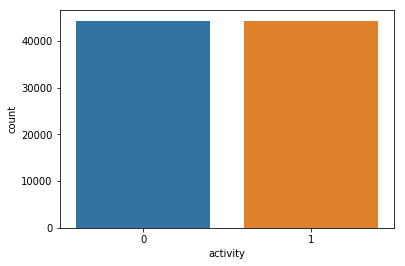

In [7]:
sns.countplot(runorwalk.activity)

## 3. Building Machine Learning Naive Bayes Models

### 3.1 Gaussian Naive Bayes Classification with both acceleration and Gyro

In [8]:
#Split the data
# Here usernameis string and date time are object, these not req, so we will remove from X

#ANOTHER WAY
#X, Y = runorwalk.iloc[:, 5:].values,runorwalk.iloc[:, 4].values
X = runorwalk.loc[:,:]
X = X.drop(["activity","date", "time","username","wrist"], axis=1)
Y = runorwalk.loc[:,["activity"]]
Y[:5]


,activity
0,0
1,0
2,0
3,0
4,0


In [9]:
#SPlit train test
train_X,test_X,train_Y,test_Y = train_test_split(X,Y,test_size=.2, random_state=5)

In [10]:
from sklearn.naive_bayes import GaussianNB
NB_reg = GaussianNB()
NB_reg.fit(train_X, train_Y)
NB_pred_y = NB_reg.predict(test_X)
print("Naive Bayes Regression Accuracy: " ,metrics.accuracy_score(test_Y, NB_pred_y))

Naive Bayes Regression Accuracy:  0.9565978101365843


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### 3.2 Repeat the model once using only the acceleration values as predictors

In [11]:
X_A = runorwalk.loc[:,["acceleration_x","acceleration_y","acceleration_z"]]
Y_A = runorwalk.loc[:,["activity"]]


In [12]:
#SPlit train test
trainA_X,testA_X,trainA_Y,testA_Y = train_test_split(X_A,Y_A,test_size=.2, random_state=5)


NB_reg1 = GaussianNB()
NB_reg1.fit(trainA_X, trainA_Y)
NB_pred_y1 = NB_reg1.predict(testA_X)
print("Naive Bayes Regression Accuracy with Acceleration: " ,metrics.accuracy_score(testA_Y, NB_pred_y1))

Naive Bayes Regression Accuracy with Acceleration:  0.9584038830567784


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### 3.3 Repeat the model once using only the Gyro values as predictors

In [13]:
X_G = runorwalk.loc[:,["gyro_x","gyro_y","gyro_z"]]
Y_G = runorwalk.loc[:,["activity"]]

#SPlit train test
trainG_X,testG_X,trainG_Y,testG_Y = train_test_split(X_G,Y_G,test_size=.2, random_state=5)


NB_reg2 = GaussianNB()
NB_reg2.fit(trainG_X, trainG_Y)
NB_pred_y2 = NB_reg2.predict(testG_X)
print("Naive Bayes Regression Accuracy with Gyro: " ,metrics.accuracy_score(testG_Y, NB_pred_y2))

Naive Bayes Regression Accuracy with Gyro:  0.6452759905181171


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## 4. Model Evaluation

### 4.1 Model Evaluation - Accuracy Score

In [14]:
print("Naive Bayes Regression Accuracy: " ,metrics.accuracy_score(test_Y, NB_pred_y))
print("Naive Bayes Regression Accuracy with Acceleration: " ,metrics.accuracy_score(testA_Y, NB_pred_y1))
print("Naive Bayes Regression Accuracy with Gyro: " ,metrics.accuracy_score(testG_Y, NB_pred_y2))

Naive Bayes Regression Accuracy:  0.9565978101365843
Naive Bayes Regression Accuracy with Acceleration:  0.9584038830567784
Naive Bayes Regression Accuracy with Gyro:  0.6452759905181171


### 4.2. Model Evaluation - confusion_matrix  

In [15]:
#confusion_matrix 
from sklearn.metrics import confusion_matrix


print("\n Confusion_matrix with All Field: \n" ,confusion_matrix(test_Y, NB_pred_y , labels =[0,1]))
print("\n Confusion_matrix with Accelerate: \n" ,confusion_matrix(testA_Y, NB_pred_y1))
print("\n Confusion_matrix with Gyro : \n" ,confusion_matrix(testG_Y, NB_pred_y2))


 Confusion_matrix with All Field: 
 [[8790   93]
 [ 676 8159]]

 Confusion_matrix with Accelerate: 
 [[8818   65]
 [ 672 8163]]

 Confusion_matrix with Gyro : 
 [[6600 2283]
 [4002 4833]]


(Text(83.40000000000006, 0.5, 'Predicted'),)

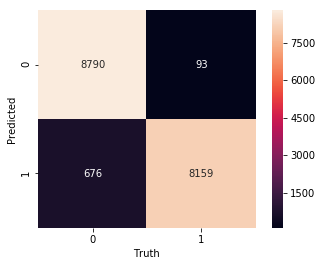

In [19]:
import matplotlib.pyplot as plt

mat = confusion_matrix(test_Y, NB_pred_y)
sns.heatmap(mat,
            fmt='d',
            square=True,
            cbar=True,
            annot=True,
            xticklabels=[0,1],
            yticklabels=[0,1]) # This should be distinct classes

# Same can be done for all 3
plt.xlabel('Truth'),
plt.ylabel('Predicted'),

### 4.3. Model Evaluation - classification_report  

In [17]:
#Classification Report AND confusion matrix

from sklearn.metrics import classification_report


target_names = ["Walk","Run"]
print("Classification_report  with All Field: \n" ,classification_report(test_Y, NB_pred_y, target_names=target_names))
print("Classification_report  with Accelerate: \n" ,classification_report(testA_Y, NB_pred_y1, target_names=target_names))
print("Classification_report with Gyro: \n" ,classification_report(testG_Y, NB_pred_y2, target_names=target_names))



Classification_report  with All Field: 
               precision    recall  f1-score   support

        Walk       0.93      0.99      0.96      8883
         Run       0.99      0.92      0.95      8835

   micro avg       0.96      0.96      0.96     17718
   macro avg       0.96      0.96      0.96     17718
weighted avg       0.96      0.96      0.96     17718

Classification_report  with Accelerate: 
               precision    recall  f1-score   support

        Walk       0.93      0.99      0.96      8883
         Run       0.99      0.92      0.96      8835

   micro avg       0.96      0.96      0.96     17718
   macro avg       0.96      0.96      0.96     17718
weighted avg       0.96      0.96      0.96     17718

Classification_report with Gyro: 
               precision    recall  f1-score   support

        Walk       0.62      0.74      0.68      8883
         Run       0.68      0.55      0.61      8835

   micro avg       0.65      0.65      0.65     17718
   macro a

### 4.4. Model Evaluation - ROC  

[1.         0.06555303 0.02430886 1.         0.04032249]
[1.         0.05261873 0.01207122 1.         0.08658848]
[0.29134502 0.55944157 0.67213179 0.44783201 0.30825158]
Area under curve with all field 0.9927568355291749
Area under curve with accelerate 0.9882276294972412
Area under curve with Gyro 0.7029788686617787


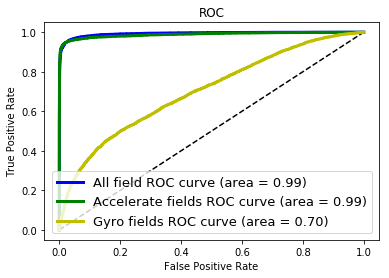

In [18]:
#ROC Curve with AUC
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

#Predictor_score LOG REG
y_pred_prob_LogR = NB_reg.predict_proba(test_X)[:,1]
print(y_pred_prob_LogR[0:5])

#Predictor_score DT
y_pred_prob_A = NB_reg1.predict_proba(testA_X)[:,1]
print(y_pred_prob_A[0:5])

#Predictor_score RF
y_pred_prob_G = NB_reg2.predict_proba(testG_X)[:,1]
print(y_pred_prob_G[0:5])



# ROC curve Log Reg
fpr_LogR, tpr_LogR, thresholds_LogR = roc_curve(test_Y, y_pred_prob_LogR)

roc_auc_logR = auc(fpr_LogR, tpr_LogR)
print("Area under curve with all field %s" %roc_auc_logR)

# ROC curve accelerate
fpr_A, tpr_A, thresholds_A = roc_curve(testA_Y, y_pred_prob_A)

roc_auc_A = auc(fpr_A, tpr_A)
print("Area under curve with accelerate %s" %roc_auc_A)

# ROC curve Gyro
fpr_G, tpr_G, thresholds_G = roc_curve(testG_Y, y_pred_prob_G)

roc_auc_G = auc(fpr_G, tpr_G)
print("Area under curve with Gyro %s" %roc_auc_G)




# Plot ROC Diagnol curve
plt.plot([0, 1], [0, 1], 'k--')

#plt.plot(fpr, tpr)  # X axis false +ve rate, Y axis True +ve rate

# Or with AUC
plt.plot(fpr_LogR, tpr_LogR, color = 'b', lw=3, label='All field ROC curve (area = {:0.2f})'.format(roc_auc_logR))
plt.plot(fpr_A, tpr_A, color = 'g', lw=3, label='Accelerate fields ROC curve (area = {:0.2f})'.format(roc_auc_A))
plt.plot(fpr_G, tpr_G, color = 'y', lw=3, label='Gyro fields ROC curve (area = {:0.2f})'.format(roc_auc_G))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=13)
plt.title('ROC')
plt.show()
## Compared to Prev method  this Grid seach approach has little less AUC

## 5 CONCLUSION: 
### Model using only the GYRO values as predictors gives 64% accuracy, but Model using only the acceleration values as predictors give 95.8% accuracy.

So we should consider accelaration values in prediction


#### ROC curve for all field or accelearte field has more Area, so its best model